In [283]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression

IMPORTING ALL THE DATASETS

In [284]:
matches = pd.read_csv("matches_1930_2022.csv")
rank2022 = pd.read_csv("fifa_ranking_2022-10-06.csv")
rank2026 = pd.read_csv("fifa_ranking_2026-06-08.csv")
world_cup = pd.read_csv("world_cup.csv")
schedule = pd.read_csv("schedule_2026.csv")


TAKING IDEA OF DATA SETS

In [285]:
matches.shape

(964, 44)

In [286]:
matches.head()

,home_team,away_team,home_score,home_xg,home_penalty,away_score,away_xg,away_penalty,home_manager,home_captain,...,home_penalty_shootout_miss_long,away_penalty_shootout_miss_long,home_red_card,away_red_card,home_yellow_red_card,away_yellow_red_card,home_yellow_card_long,away_yellow_card_long,home_substitute_in_long,away_substitute_in_long
0,Argentina,France,3,3.3,4.0,3,2.2,2.0,Lionel Scaloni,Lionel Messi,...,NaN,"['3|1:1|Kingsley Coman', '5|2:1|Aurélien Tchou...",NaN,NaN,NaN,NaN,"['45+7&rsquor;|2:0|Enzo Fernández', '90+8&rsqu...","['55&rsquor;|2:0|Adrien Rabiot', '87&rsquor;|2...",['64&rsquor;|2:0|Marcos Acuña|for Ángel Di Mar...,['41&rsquor;|2:0|Randal Kolo Muani|for Ousmane...
1,Croatia,Morocco,2,0.7,NaN,1,1.2,NaN,Zlatko Dalić,Luka Modrić,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,"['69&rsquor;|2:1|Azzedine Ounahi', '84&rsquor;...",['61&rsquor;|2:1|Nikola Vlašić|for Andrej Kram...,['46&rsquor;|2:1|Ilias Chair|for Abdelhamid Sa...
2,France,Morocco,2,2.0,NaN,0,0.9,NaN,Didier Deschamps,Hugo Lloris,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,['27&rsquor;|1:0|Sofiane Boufal'],['65&rsquor;|1:0|Marcus Thuram|for Olivier Gir...,['21&rsquor;|1:0|Selim Amallah|for Romain Saïs...
3,Argentina,Croatia,3,2.3,NaN,0,0.5,NaN,Lionel Scaloni,Lionel Messi,...,NaN,NaN,NaN,NaN,NaN,NaN,"['68&rsquor;|2:0|Cristian Romero', '71&rsquor;...","['32&rsquor;|0:0|Mateo Kovačić', '32&rsquor;|0...",['62&rsquor;|2:0|Lisandro Martínez|for Leandro...,"['46&rsquor;|2:0|Mislav Oršić|for Borna Sosa',..."
4,Morocco,Portugal,1,1.4,NaN,0,0.9,NaN,Hoalid Regragui,Romain Saïss,...,NaN,NaN,NaN,NaN,Walid Cheddira · 90+3,NaN,"['70&rsquor;|1:0|Achraf Dari', '90+1&rsquor;|1...",['87&rsquor;|1:0|Vitinha'],['57&rsquor;|1:0|Achraf Dari|for Romain Saïss'...,['51&rsquor;|1:0|João Cancelo|for Raphaël Guer...


In [287]:
rank2022.shape

(211, 7)

In [288]:
rank2022.head()

,team,team_code,association,rank,previous_rank,points,previous_points
0,Brazil,BRA,CONMEBOL,1,1,1841.30,1837.56
1,Belgium,BEL,UEFA,2,2,1816.71,1821.92
2,Argentina,ARG,CONMEBOL,3,3,1773.88,1770.65
3,France,FRA,UEFA,4,4,1759.78,1764.85
4,England,ENG,UEFA,5,5,1728.47,1737.46


In [289]:
world_cup.head()

,Year,Host,Teams,Champion,Runner-Up,TopScorrer,Attendance,AttendanceAvg,Matches
0,2022,Qatar,32,Argentina,France,Kylian Mbappé - 8,3404252,53191,64
1,2018,Russia,32,France,Croatia,Harry Kane - 6,3031768,47371,64
2,2014,Brazil,32,Germany,Argentina,James Rodríguez - 6,3429873,53592,64
3,2010,South Africa,32,Spain,Netherlands,"Wesley Sneijder, Thomas Müller... - 5",3178856,49670,64
4,2006,Germany,32,Italy,France,Miroslav Klose - 5,3352605,52384,64


In [290]:
world_cup.shape

(22, 9)

In [291]:
schedule.head()


,Round,Day,Date,Time,Score,Referee,Notes,Year,home_team,away_team
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,Korea Republic,Czechia
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina
3,Group stage,Fri,2026-06-12,18:00 (04:00),NaN,NaN,NaN,2026,United States,Paraguay
4,Group stage,Sat,2026-06-13,12:00 (22:00),NaN,NaN,NaN,2026,Qatar,Switzerland


In [292]:
schedule.shape

(72, 10)

CHECKING FOR NULL VALUES

In [293]:
matches.isnull().sum().sort_values(ascending=False)

home_penalty_miss_long             958
away_penalty_miss_long             955
away_own_goal                      947
home_yellow_red_card               941
home_penalty_shootout_miss_long    940
away_penalty_shootout_miss_long    934
away_yellow_red_card               933
home_penalty_shootout_goal_long    930
away_penalty_shootout_goal_long    930
home_penalty                       929
away_penalty                       929
home_own_goal                      925
home_red_card                      913
away_red_card                      910
Notes                              891
away_penalty_goal                  880
home_penalty_goal                  848
away_xg                            836
home_xg                            836
away_goal                          393
away_goal_long                     393
home_yellow_card_long              343
away_yellow_card_long              337
away_captain                       320
home_captain                       320
Officials                

FILLING THE NULL VALUES USING IMPUTER FROM SK_LEARN 

In [294]:
categorical_cols = matches.select_dtypes(include=["object"]).columns
numerical_cols = matches.select_dtypes(include=["number"]).columns

In [295]:
from sklearn.impute import SimpleImputer
num_imp = SimpleImputer(strategy="mean")
matches[numerical_cols] = num_imp.fit_transform(matches[numerical_cols])

In [296]:
cat_imp = SimpleImputer(strategy="most_frequent")
matches[categorical_cols] = cat_imp.fit_transform(matches[categorical_cols])

CHECKING FOR DUPLICATES - as if they exist may negatively effect our model (model may become bias due to duplicate values)

In [297]:
print(matches.duplicated().sum())
print(rank2022.duplicated().sum())
print(rank2026.duplicated().sum())
print(world_cup.duplicated().sum())
print(schedule.duplicated().sum())

0
0
0
0
0


In [298]:
matches.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 964 entries, 0 to 963
Data columns (total 44 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   home_team                        964 non-null    object 
 1   away_team                        964 non-null    object 
 2   home_score                       964 non-null    float64
 3   home_xg                          964 non-null    float64
 4   home_penalty                     964 non-null    float64
 5   away_score                       964 non-null    float64
 6   away_xg                          964 non-null    float64
 7   away_penalty                     964 non-null    float64
 8   home_manager                     964 non-null    object 
 9   home_captain                     964 non-null    object 
 10  away_manager                     964 non-null    object 
 11  away_captain                     964 non-null    object 
 12  Attendance            

CHANGING DTYPE OF DATE COLUMN AS WE WILL LATER NEED TO EXTRACT YEAR FROM IT FOR TEMPORAL SPLIT

In [299]:
matches["Date"] = pd.to_datetime(matches["Date"])

In [300]:
matches["Date"]

0     2022-12-18
1     2022-12-17
2     2022-12-14
3     2022-12-13
4     2022-12-10
         ...    
959   1930-07-15
960   1930-07-14
961   1930-07-14
962   1930-07-13
963   1930-07-13
Name: Date, Length: 964, dtype: datetime64[ns]

In [301]:
matches["Year"] = matches["Date"].dt.year

In [302]:
matches["Year"]

0      2022
1      2022
2      2022
3      2022
4      2022
       ... 
959    1930
960    1930
961    1930
962    1930
963    1930
Name: Year, Length: 964, dtype: int32

DUE TO COUNTRY MISMATCH CREATING A DICTIONARY TO MAP TO THE DATAFRAME, TO STANDARDIZE THE NAMES

In [303]:
country_mapping = {
    "USA":"United States",
    "IR Iran":"Iran",
    "Korea Republic":"South Korea",
    "Korea DPR":"North Korea",
    "West Germany": "Germany",
    "Germany DR": "Germany"
}

In [304]:
matches["home_team"].unique()

array(['Argentina', 'Croatia', 'France', 'Morocco', 'England',
       'Netherlands', 'Portugal', 'Japan', 'Brazil', 'Korea Republic',
       'Ghana', 'Cameroon', 'Serbia', 'Canada', 'Costa Rica', 'Australia',
       'Tunisia', 'Saudi Arabia', 'Poland', 'Ecuador', 'IR Iran', 'Wales',
       'Belgium', 'Spain', 'Qatar', 'Switzerland', 'Uruguay', 'Germany',
       'Denmark', 'Mexico', 'Senegal', 'United States', 'Sweden',
       'Russia', 'Colombia', 'Panama', 'Iceland', 'Nigeria', 'Peru',
       'Egypt', 'Algeria', 'Bosnia and Herzegovina', 'Honduras', 'Italy',
       'Greece', "Côte d'Ivoire", 'Chile', 'Paraguay', 'Korea DPR',
       'Slovakia', 'Slovenia', 'South Africa', 'New Zealand', 'Ukraine',
       'Togo', 'Czech Republic', 'Serbia and Montenegro', 'Angola',
       'Trinidad and Tobago', 'Türkiye', 'China PR',
       'Republic of Ireland', 'Romania', 'Scotland', 'FR Yugoslavia',
       'Jamaica', 'Bulgaria', 'Bolivia', 'Norway', 'West Germany',
       'Yugoslavia', 'Czechoslovaki

In [305]:
matches["away_team"].unique()

array(['France', 'Morocco', 'Croatia', 'Portugal', 'Brazil', 'Argentina',
       'Spain', 'Switzerland', 'Korea Republic', 'Poland', 'Senegal',
       'United States', 'Australia', 'Uruguay', 'Belgium', 'Germany',
       'Denmark', 'Mexico', 'Qatar', 'England', 'Serbia', 'Ghana',
       'Costa Rica', 'Canada', 'Saudi Arabia', 'IR Iran', 'Ecuador',
       'Cameroon', 'Japan', 'Tunisia', 'Netherlands', 'Wales', 'Russia',
       'Colombia', 'Sweden', 'Peru', 'Egypt', 'Panama', 'Iceland',
       'Nigeria', 'Algeria', 'Greece', 'Chile', "Côte d'Ivoire",
       'Bosnia and Herzegovina', 'Honduras', 'Italy', 'Slovakia',
       'New Zealand', 'South Africa', 'Korea DPR', 'Paraguay', 'Slovenia',
       'Ukraine', 'Angola', 'Serbia and Montenegro',
       'Trinidad and Tobago', 'Togo', 'Czech Republic', 'Türkiye',
       'Republic of Ireland', 'China PR', 'FR Yugoslavia', 'Norway',
       'Jamaica', 'Bulgaria', 'Austria', 'Scotland', 'Romania', 'Bolivia',
       'Czechoslovakia', 'Yugoslavia', '

In [306]:
matches["home_team"] = matches["home_team"].replace(country_mapping)
matches["away_team"] = matches["away_team"].replace(country_mapping)

rank2022["team"] = rank2022["team"].replace(country_mapping)
rank2026["team"] = rank2026["team"].replace(country_mapping)

schedule["home_team"] = schedule["home_team"].replace(country_mapping)
schedule["away_team"] = schedule["away_team"].replace(country_mapping)

REMOVING IF ANY SPACES IN FRONT OR BACK OF COUNTRY NAME

In [307]:
matches["home_team"] = matches["home_team"].str.strip()
matches["away_team"] = matches["away_team"].str.strip()

rank2022["team"] = rank2022["team"].str.strip()
rank2026["team"] = rank2026["team"].str.strip()

schedule["home_team"] = schedule["home_team"].str.strip()
schedule["away_team"] = schedule["away_team"].str.strip()

MERGING THE REQUIRED COLUMNS FROM OTHER DATASETS TO MATCHES DATAFRAME FOR FURTHER USE (LIKE MAKING NEW FEATURES, FOR ML MODEL FEEDING)
DROPPING THE REDUNDANT COLOMN AFTER EACH MERGE

In [308]:
matches = matches.merge(
    rank2022[["team", "rank"]],
    left_on = "home_team",
    right_on = "team",
    how = "left"
)

In [309]:
matches.drop(columns = "team", inplace = True)

In [310]:
matches.rename(columns = {"rank" : "home_rank"},
               inplace = True
              )

In [311]:
matches = matches.merge(
    rank2022[["team", "rank"]],
    left_on = "away_team",
    right_on = "team",
    how = "left"
)

In [312]:
matches.rename(columns = {"rank" : "away_rank"},
               inplace = True
)

matches.drop(columns = "team", inplace = True)

FILLING THE MISSING VALUES IN NEW MERGED DF

In [313]:
matches["home_rank"] = matches["home_rank"].fillna(matches["home_rank"].median())
matches["away_rank"] = matches["away_rank"].fillna(matches["away_rank"].median())

In [314]:
matches.isnull().sum()

home_team                          0
away_team                          0
home_score                         0
home_xg                            0
home_penalty                       0
away_score                         0
away_xg                            0
away_penalty                       0
home_manager                       0
home_captain                       0
away_manager                       0
away_captain                       0
Attendance                         0
Venue                              0
Officials                          0
Round                              0
Date                               0
Score                              0
Referee                            0
Notes                              0
Host                               0
Year                               0
home_goal                          0
away_goal                          0
home_goal_long                     0
away_goal_long                     0
home_own_goal                      0
a

<-------------------------------------------------EDA--------------------------------------------------->

In [315]:
print("Score statistics")
print(matches[['home_score','away_score']].describe().round(2))

Score statistics
       home_score  away_score
count      964.00      964.00
mean         1.78        1.04
std          1.60        1.07
min          0.00        0.00
25%          1.00        0.00
50%          1.00        1.00
75%          3.00        2.00
max         10.00        7.00


<Axes: >

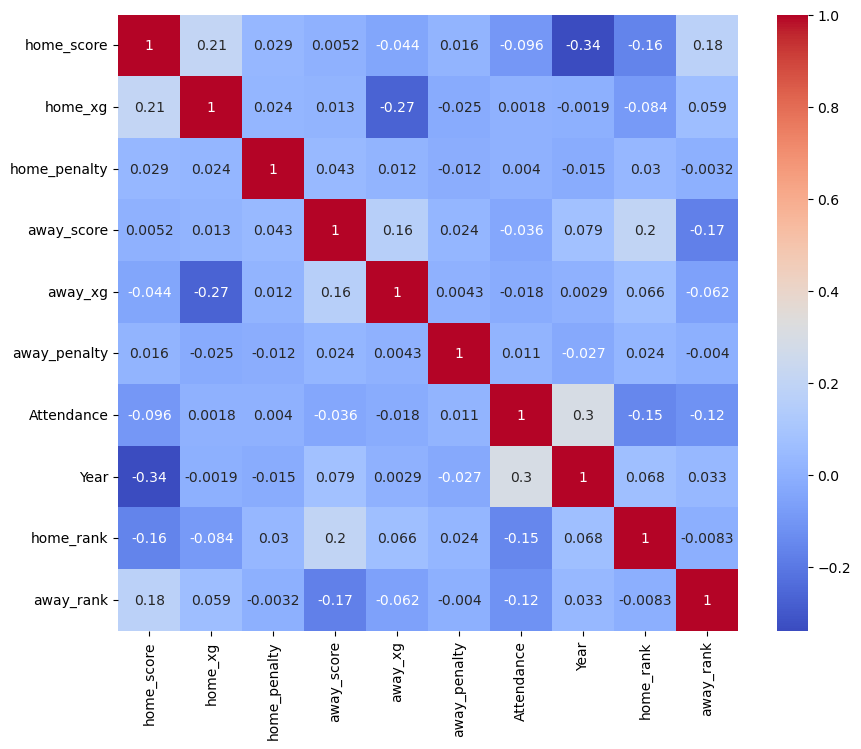

In [316]:
plt.figure(figsize = (10,8))

sns.heatmap(
    matches.corr(numeric_only = True),
    annot = True,
    cmap = "coolwarm"
)

BY ABOVE WE CAN SAY THAT HOME_RANK AND AWAY_RANK HAVE SOME CORRELATION WITH HOME_SCORE AND AWAY_SCORE BUT WITH OTHER FEATURES WE CANT SAY SO THEY HAVE VERY SMALL CORRELATION COEFFICIENT

In [317]:
top_goals = matches.groupby("home_team")["home_score"].sum().sort_values(ascending = False).head(10)

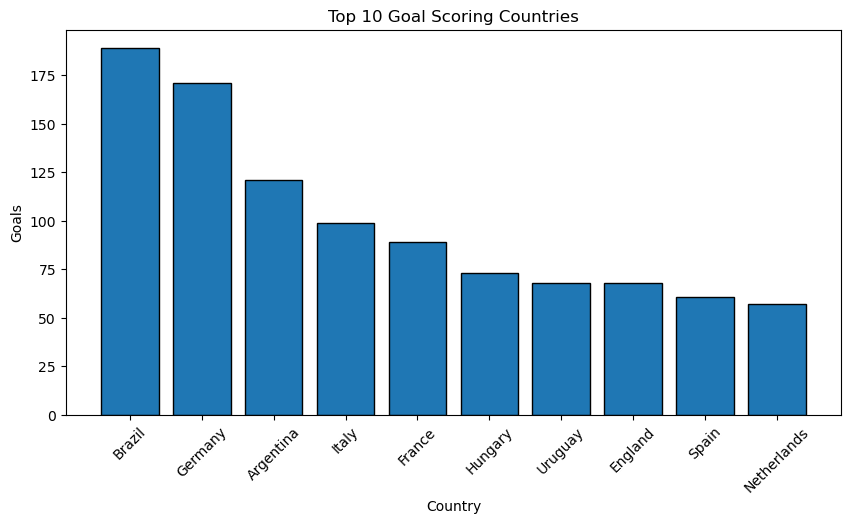

In [318]:
fig, ax = plt.subplots(figsize=(10, 5))
bar = ax.bar(top_goals.index, top_goals.values, edgecolor = "black")
plt.xticks(rotation=45)
plt.xlabel("Country")
plt.ylabel("Goals")
plt.title("Top 10 Goal Scoring Countries")
plt.show()

ENCODING


In [319]:
def match_result(row):
    if row["home_score"] > row["away_score"]:
        return 0

    elif row["away_score"] > row["home_score"]:
        return 1

    else:
        return 2


matches["Match_Result"] = matches.apply(match_result, axis=1)

ADDING FEATURES

1. RANK DIFF
Rank_Diff = Away Team Rank - Home Team Rank
THIS FEATURE MEASURES THE DIFFERENCE IN HISTORICAL RANKING BETWEEN THE TWO TEAMS, WHERE A LARGER POSITIVE VALUE INDICATES THE HOME TEAM IS HIGHER RANKED

In [320]:
matches["Rank_Diff"] = (matches["away_rank"] - matches["home_rank"])

2. HOME_WIN_RATE
THIS FEATURE MEASURES THE PERCENTAGE THE TEAMS WIN AT HOME GROUND
THIS HELPS IN PREDICTION OF TEAM WINNING A MATCH Y KNOWING HOW WEEL IT PERFORMS AT HOME GROUND

In [321]:
home_stats = matches.groupby("home_team")["Match_Result"].apply( lambda x: (x == 0).mean() )

matches["Home_Win_Rate"] = matches["home_team"].map(home_stats)

3. AWAY_WIN_RATE
MEASURES THE PERCENTAGE THE TEAMS WIN AT OTHER GROUNDS
THIS FEATURE HELPS IN PREDICTION OF TEAM WINNING A MATCH Y KNOWING HOW WEEL IT PERFORMS AT RIVAL GROUND
COMPARISON OF HOME WIN RATE AND AWAY WIN RATE WILL BE HELPFUL IN PREDICTION

In [322]:
away_stats = matches.groupby("away_team")["Match_Result"].apply(
    lambda x: (x == 1).mean()
)

matches["Away_Win_Rate"] = matches["away_team"].map(away_stats)

4. GOAL AVERAGE DIFFERENCE
THIS FEATURE MEASURES THE DIFFERENCE IN HISTORICAL AVERAGE GOALS SCORED PER MATCH BETWEEN THE TWO TEAMS

In [323]:
home_goals = matches.groupby("home_team")["home_score"].sum()
away_goals = matches.groupby("away_team")["away_score"].sum() 

total_goals = home_goals.add(away_goals, fill_value=0) #need fill value to avoid getting Nan when adding

home_matches = matches["home_team"].value_counts()
away_matches = matches["away_team"].value_counts()

total_matches = home_matches.add(away_matches, fill_value=0)
goal_avg = total_goals / total_matches

matches["Home_Avg_Goals"] = (matches["home_team"].map(goal_avg) )
matches["Away_Avg_Goals"] = (matches["away_team"].map(goal_avg) )
matches["Goal_Avg_Diff"] = (matches["Home_Avg_Goals"]- matches["Away_Avg_Goals"])

5. TEAM EXPIRIENCE_DIFF
MORE EXPIRIENCED TEAM IS EXPECTED TO PLAY BETTER THUS HAVE HIGHER CHANCE OF WINNING

In [324]:
home_exp = matches["home_team"].value_counts()
away_exp = matches["away_team"].value_counts()
total_exp = home_exp.add(away_exp, fill_value=0)
matches["Home_Experience"] = matches["home_team"].map(total_exp)
matches["Away_Experience"] = matches["away_team"].map(total_exp)
matches["Experience_Diff"] = (matches["Home_Experience"]-matches["Away_Experience"])

TEMPORAL SPLIT


In [325]:
train_data = matches[matches["Year"] <= 2018]
test_data = matches[matches["Year"] == 2022]

In [326]:
features = ["home_rank", "away_rank", "Rank_Diff", "Home_Win_Rate", "Away_Win_Rate", "Goal_Avg_Diff"]
X_train = train_data[features]
y_train = train_data["Match_Result"]

X_test = test_data[features]
y_test = test_data["Match_Result"]

In [327]:
# SCALING 
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [328]:
# LOGISTIC REGRESSION
lr_model = LogisticRegression(max_iter = 1000)
lr_model.fit(X_train_scaled, y_train)
lr_y_pred = lr_model.predict(X_test_scaled)

print("Logistic Regression")
print("Accuracy : ", accuracy_score(y_test,lr_y_pred))
print("Precision : ", precision_score(y_test,lr_y_pred, average = "macro"))
print("Recall : ", recall_score(y_test,lr_y_pred,  average = "macro"))
print("F1_score : ", f1_score(y_test,lr_y_pred, average = "macro"))

Logistic Regression
Accuracy :  0.5625
Precision :  0.503774154589372
Recall :  0.5080459770114942
F1_score :  0.4988880416825518


In [329]:
rf_model = RandomForestClassifier(n_estimators=200)
rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy:", accuracy_score(y_test, rf_y_pred))
print("Precision:", precision_score(y_test, rf_y_pred, average="macro"))
print("Recall:", recall_score(y_test, rf_y_pred, average="macro"))
print("F1 Score:", f1_score(y_test, rf_y_pred, average="macro"))

Random Forest
Accuracy: 0.578125
Precision: 0.5471380471380471
Recall: 0.5354406130268199
F1 Score: 0.5325140809011776


In [330]:
#RANDOM FOREST CLASSIFIER WITH CROSS VALIDATION
classifier = RandomForestClassifier(random_state=42)
param_grid = {"n_estimators": [100, 200, 300]} #took less hyperparameters as notebook would hang on CV for more hyperparameters

rf_model = GridSearchCV(
    classifier,
    param_grid=param_grid,
    cv=5,
    scoring="f1_macro",
    n_jobs=-1
)

rf_model.fit(X_train, y_train)
rf_y_pred = rf_model.predict(X_test)

print("Random Forest")
print("Accuracy : ", accuracy_score(y_test,rf_y_pred))
print("Precision : ", precision_score(y_test,rf_y_pred, average = "macro"))
print("Recall : ", recall_score(y_test,rf_y_pred,  average = "macro"))
print("F1_score : ", f1_score(y_test,rf_y_pred, average = "macro"))


Random Forest
Accuracy :  0.59375
Precision :  0.5529100529100529
Recall :  0.5362068965517242
F1_score :  0.5279322303712547


In [331]:
schedule.head()

,Round,Day,Date,Time,Score,Referee,Notes,Year,home_team,away_team
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,South Korea,Czechia
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina
3,Group stage,Fri,2026-06-12,18:00 (04:00),NaN,NaN,NaN,2026,United States,Paraguay
4,Group stage,Sat,2026-06-13,12:00 (22:00),NaN,NaN,NaN,2026,Qatar,Switzerland


In [332]:
#MERGING REQUIRED DATA FROM OTHER DATASETS TO SCHEDULE DATAFRAME 
home_rank_df = rank2026[["team", "rank"]]

schedule = schedule.merge(
    home_rank_df,
    left_on="home_team",
    right_on="team",
    how="left"
)

schedule.rename(
    columns={"rank": "home_rank"},
    inplace=True
)

schedule.drop(
    columns=["team"],
    inplace=True
)

In [333]:
away_rank_df = rank2026[["team", "rank"]]

schedule = schedule.merge(
    away_rank_df,
    left_on="away_team",
    right_on="team",
    how="left"
)

schedule.rename(
    columns={"rank": "away_rank"},
    inplace=True
)

schedule.drop(
    columns=["team"],
    inplace=True
)

In [334]:
schedule.head()

,Round,Day,Date,Time,Score,Referee,Notes,Year,home_team,away_team,home_rank,away_rank
0,Group stage,Thu,2026-06-11,13:00 (22:00),NaN,NaN,NaN,2026,Mexico,South Africa,14.0,60.0
1,Group stage,Thu,2026-06-11,20:00 (05:00),NaN,NaN,NaN,2026,South Korea,Czechia,25.0,39.0
2,Group stage,Fri,2026-06-12,15:00 (22:00),NaN,NaN,NaN,2026,Canada,Bosnia-Herzegovina,30.0,NaN
3,Group stage,Fri,2026-06-12,18:00 (04:00),NaN,NaN,NaN,2026,United States,Paraguay,17.0,40.0
4,Group stage,Sat,2026-06-13,12:00 (22:00),NaN,NaN,NaN,2026,Qatar,Switzerland,57.0,19.0


In [335]:
schedule["Home_Win_Rate"] = schedule["home_team"].map(home_stats)
schedule["Away_Win_Rate"] = schedule["away_team"].map(away_stats)
schedule["Goal_Avg_Diff"] = schedule["home_team"].map(goal_avg) - schedule["away_team"].map(goal_avg)
schedule["Rank_Diff"] = schedule["away_rank"] - schedule["home_rank"]


In [336]:
X_2026 = schedule[
    [   "home_rank",
        "away_rank",
        "Rank_Diff",
        "Home_Win_Rate",
        "Away_Win_Rate",
        "Goal_Avg_Diff"
    ] ].copy()

In [337]:
X_2026.isnull().sum()

home_rank         2
away_rank         4
Rank_Diff         6
Home_Win_Rate     9
Away_Win_Rate    12
Goal_Avg_Diff    20
dtype: int64

In [338]:
for col in X_2026.columns:
    X_2026[col] = X_2026[col].fillna( X_train[col].median() )

In [339]:
probs = rf_model.predict_proba(X_2026)

schedule["Home Win %"] = probs[:,0] * 100
schedule["Away Win %"] = probs[:,1] * 100
schedule["Draw %"] = probs[:,2] * 100

probability = schedule[
    [ "home_team",
      "away_team",
      "Home Win %",
      "Away Win %",
      "Draw %" ]
].head(10).round(2)

In [340]:
print(probability)

       home_team           away_team  Home Win %  Away Win %  Draw %
0         Mexico        South Africa       37.00       46.00   17.00
1    South Korea             Czechia       38.17       42.50   19.33
2         Canada  Bosnia-Herzegovina       17.60       35.40   47.00
3  United States            Paraguay       65.67       26.00    8.33
4          Qatar         Switzerland        3.33       80.67   16.00
5         Brazil             Morocco       61.32       13.95   24.72
6          Haiti            Scotland        1.83       50.17   48.00
7      Australia             Türkiye       30.08       61.17    8.75
8        Germany             Curaçao       72.97        9.50   17.53
9    Netherlands               Japan       46.44       19.67   33.89


In [341]:
matches["Total_Goals"] = matches["home_score"] + matches["away_score"]

train_data = matches[matches["Year"] <= 2018]
test_data = matches[matches["Year"] == 2022]

X_train_reg = train_data[features]
y_train_reg = train_data["Total_Goals"]

X_test_reg = test_data[features]
y_test_reg = test_data["Total_Goals"]

scaler = StandardScaler()

X_train_reg_scaled = scaler.fit_transform(X_train_reg)
X_test_reg_scaled = scaler.transform(X_test_reg)

lr_reg = LinearRegression()
lr_reg.fit(X_train_reg_scaled, y_train_reg)
goal_pred = lr_reg.predict(X_test_reg_scaled)

print("MAE:", mean_absolute_error(y_test_reg, goal_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test_reg, goal_pred)))

MAE: 1.4152977833766651
RMSE: 1.8238352876339263


MAE TELLS HERE WHAT IS THE AVERAGE GOAL DIFFERENCE PER MATCH IN OUR PREDICTED AND ACTUAL VALUES